# Survival Analysis & Sensitivity Analyses
**Study:** APOE ε4 × Hippocampal Volume × Cognitive Decline

This notebook covers:
1. **Survival/Conversion Analysis** — Cox PH model for CN → MCI/AD conversion
2. **Kaplan-Meier Curves** by APOE dose
3. **Sensitivity Analysis 1** — Stratified by baseline diagnosis (CN, MCI, AD)
4. **Sensitivity Analysis 2** — Excluding outliers (±3 SD hippocampal volume)
5. **Sensitivity Analysis 3** — Subjects with ≥2 visits only
6. **Sensitivity Analysis 4** — Robust standard errors (MMSE ceiling effect)

Requires: `reports/ADNI_Complete_Cases.csv` and `reports/ADNI_Baseline_Analysis.csv` from `01_data_pipeline.ipynb`

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Try to import lifelines for survival analysis
try:
    from lifelines import CoxPHFitter, KaplanMeierFitter
    from lifelines.statistics import logrank_test, multivariate_logrank_test
    LIFELINES = True
    print('✓ lifelines available')
except ImportError:
    LIFELINES = False
    print('⚠ lifelines not installed — install with: pip install lifelines')
    print('  Survival analysis will be skipped')

BASE    = '/media/faizaan/4TB/1_DATA_PROJECTS/Projects/Multimodel_study'
REPORTS = os.path.join(BASE, 'reports')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
APOE_COLORS = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}

# Load data
complete = pd.read_csv(os.path.join(REPORTS, 'ADNI_Complete_Cases.csv'))
baseline = pd.read_csv(os.path.join(REPORTS, 'ADNI_Baseline_Analysis.csv'))

for df in [complete, baseline]:
    df['APOE4_DOSE']    = pd.to_numeric(df['APOE4_DOSE'], errors='coerce')
    df['HIPPO_ICV_ADJ'] = pd.to_numeric(df['HIPPO_ICV_ADJ'], errors='coerce')
    df['YEARS_FROM_BL'] = pd.to_numeric(df['YEARS_FROM_BL'], errors='coerce')
    df['MMSCORE']       = pd.to_numeric(df['MMSCORE'], errors='coerce')
    if 'SEX' in df.columns:
        df['SEX_MALE'] = (df['SEX'] == 'Male').astype(float)

print(f'Complete: {complete["RID"].nunique()} subjects, {len(complete):,} obs')
print(f'Baseline: {len(baseline)} subjects')

✓ lifelines available
Complete: 2417 subjects, 11,793 obs
Baseline: 2417 subjects


## 1. Survival Analysis — CN → MCI/AD Conversion
Using pre-computed survival variables (`Event`, `Time`) from `baseline_subj.csv`.

In [38]:
# Prepare survival dataset
# Keep CN subjects at baseline (those at risk of converting)
surv_cols_needed = ['RID', 'APOE4_DOSE', 'HIPPO_ICV_ADJ', 'HIPPO_ICV_Z',
                    'AGE', 'SEX_MALE', 'PTEDUCAT', 'BL_DX_LABEL']
event_cols = ['Event', 'Time', 'TimeMonths', 'TIME_YEARS']

available_surv = [c for c in surv_cols_needed + event_cols if c in baseline.columns]
surv_df = baseline[available_surv].copy()

# Check survival columns
has_event = 'Event' in surv_df.columns
has_time  = 'TIME_YEARS' in surv_df.columns

print(f'Survival columns available: Event={has_event}, Time={has_time}')

if has_event and has_time:
    # TIME_YEARS already converted in NB01 (was in months, now years)
    surv_df = surv_df.dropna(subset=['Event', 'TIME_YEARS', 'APOE4_DOSE', 'HIPPO_ICV_ADJ'])
    surv_df['TIME_YEARS'] = surv_df['TIME_YEARS'].clip(lower=0.01)  # avoid zero-time
    
    print(f'\nSurvival dataset: {len(surv_df)} subjects')
    print(f'Events (conversions): {surv_df["Event"].sum():.0f} ({surv_df["Event"].mean()*100:.1f}%)')
    print(f'Follow-up (years): median={surv_df["TIME_YEARS"].median():.1f}, max={surv_df["TIME_YEARS"].max():.1f}')
    print('\nEvents by APOE dose:')
    print(surv_df.groupby('APOE4_DOSE')[['Event']].agg(['sum', 'count']))
else:
    print('\n⚠ Survival variables (Event, Time) not found in baseline data.')
    print('  Will derive conversion status from longitudinal diagnosis data.')
    
    # Derive from longitudinal data
    if 'BL_DX_LABEL' in complete.columns and 'DX_LABEL' in complete.columns:
        cn_subjects = complete[complete['BL_DX_LABEL'] == 'CN']['RID'].unique()
        
        conversions = []
        for rid in cn_subjects:
            sub = complete[complete['RID'] == rid].sort_values('YEARS_FROM_BL')
            converted = (sub['DX_LABEL'].isin(['MCI', 'AD'])).any()
            if converted:
                conv_time = sub[sub['DX_LABEL'].isin(['MCI', 'AD'])]['YEARS_FROM_BL'].min()
            else:
                conv_time = sub['YEARS_FROM_BL'].max()
            conversions.append({'RID': rid, 'Event': int(converted), 'Time': conv_time})
        
        conv_df = pd.DataFrame(conversions)
        surv_df = baseline[baseline['RID'].isin(cn_subjects)].merge(conv_df, on='RID', how='inner')
        surv_df = surv_df.dropna(subset=['Event', 'Time', 'APOE4_DOSE', 'HIPPO_ICV_ADJ'])
        has_event = True
        has_time  = True
        print(f'Derived conversion: {len(surv_df)} CN subjects, {surv_df["Event"].sum():.0f} conversions')
    else:
        print('Cannot derive conversion status — no DX_LABEL in longitudinal data')
        has_event = False

Survival columns available: Event=True, Time=True

Survival dataset: 2417 subjects
Events (conversions): 845 (35.0%)
Follow-up (years): median=1.8, max=18.8

Events by APOE dose:
           Event      
             sum count
APOE4_DOSE            
0.0          303  1322
1.0          401   870
2.0          141   225


### 1.1 Kaplan-Meier Curves by APOE Dose

Log-rank test: p=0.0000


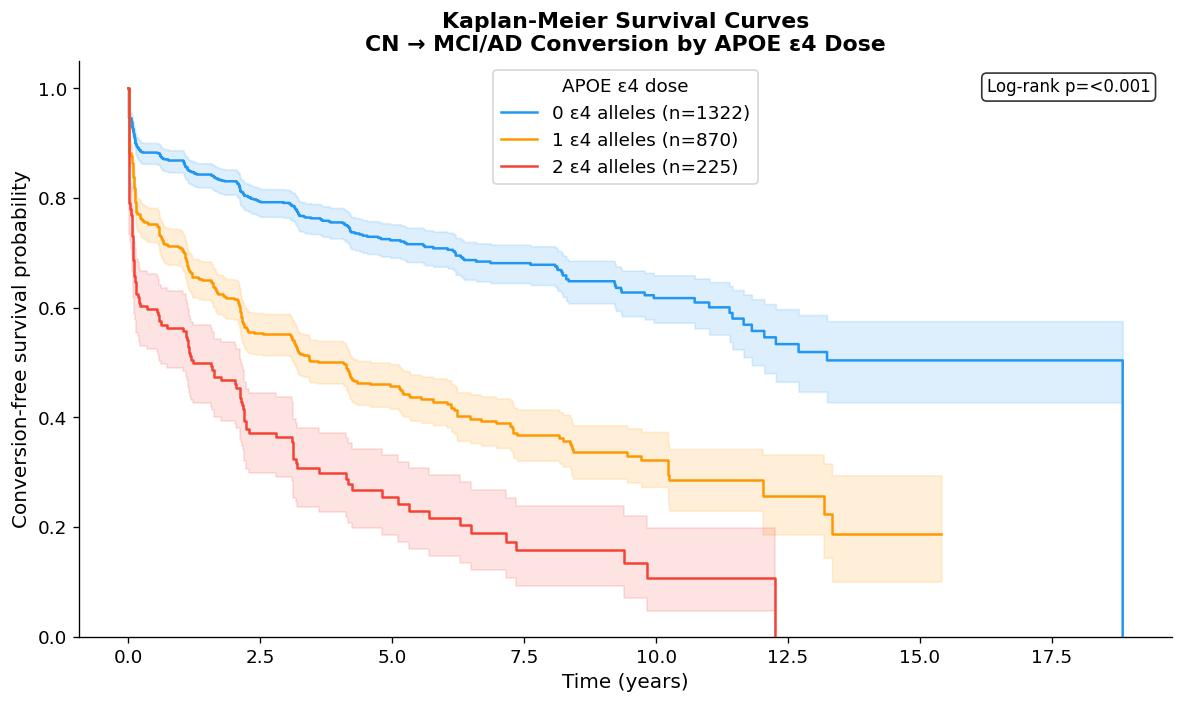

✓ Saved: Fig7_KaplanMeier.png


In [39]:
if LIFELINES and has_event and 'surv_df' in locals() and len(surv_df) > 10:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    kmfs = {}
    for dose in [0, 1, 2]:
        sub = surv_df[surv_df['APOE4_DOSE'] == dose]
        if len(sub) < 5: continue
        kmf = KaplanMeierFitter()
        kmf.fit(sub['TIME_YEARS'], sub['Event'], label=f'{dose} ε4 alleles (n={len(sub)})')
        kmf.plot_survival_function(ax=ax, color=APOE_COLORS[dose], ci_show=True, ci_alpha=0.15)
        kmfs[dose] = kmf
    
    ax.set_xlabel('Time (years)', fontsize=12)
    ax.set_ylabel('Conversion-free survival probability', fontsize=12)
    ax.set_title('Kaplan-Meier Survival Curves\nCN → MCI/AD Conversion by APOE ε4 Dose', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend(title='APOE ε4 dose')
    
    # Log-rank test
    if len(kmfs) >= 2:
        try:
            from lifelines.statistics import multivariate_logrank_test
            results_lr = multivariate_logrank_test(surv_df['TIME_YEARS'], surv_df['APOE4_DOSE'], surv_df['Event'])
            p_lr = results_lr.p_value
            ax.text(0.98, 0.97, f'Log-rank p={"<0.001" if p_lr<0.001 else f"{p_lr:.3f}"}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            print(f'Log-rank test: p={p_lr:.4f}')
        except Exception as e:
            print(f'Log-rank test failed: {e}')
    
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS, 'Fig7_KaplanMeier.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved: Fig7_KaplanMeier.png')

elif not LIFELINES:
    print('lifelines not available — install with: pip install lifelines')
else:
    print('Insufficient survival data for KM curves')

### 1.2 Cox Proportional Hazards Model

Cox model data: 2365 subjects, 812 events
Predictors: ['APOE4_DOSE', 'HIPPO_ICV_ADJ', 'AGE', 'SEX_MALE', 'PTEDUCAT', 'APOE4_x_HIPPO']


<lifelines.CoxPHFitter: fitted with 2365 total observations, 1553 right-censored observations>
             duration col = 'TIME_YEARS'
                event col = 'Event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 2365
number of events observed = 812
   partial log-likelihood = -5599.39
         time fit was run = 2026-03-23 03:44:36 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
APOE4_DOSE     0.39      1.48      0.07            0.25            0.53                1.29                1.71
HIPPO_ICV_ADJ  1.19      3.28      0.25            0.70            1.68                2.02                5.34
AGE            0.03      1.03      0.00            0.02            0.04                1.02                1.04
SEX_MALE       0.07      1.07      0.06           -0.05            0.20                0.95                1.22
PTEDUCAT      -0.06      0.95      0.01           -0.08           -0.03                0.93                0.97
APOE4_x_HIPPO  0.43      1.54      0.10            0.25            0.62                1.28                1.86

               cmp to     z      p  -log2(p)
covariate                                   
APOE4_DOSE       0.00  5.51 <0.005     24.71
HIPPO_ICV_ADJ    0.00  4.79 <0.005     19.18
AGE              0.00  5.67 <0.005     26.06
SEX_MALE         0.00  1.10   0.27      1.89
PTEDUCAT         0.00 -5.00 <0.005     20.70
APOE4_x_HIPPO    0.00  4.50 <0.005     17.19
---
Concordance = 0.70
Partial AIC = 11210.79
log-likelihood ratio test = 314.60 on 6 df
-log2(p) of ll-ratio test = 213.32


✓ Saved: Cox_PH_Results.csv


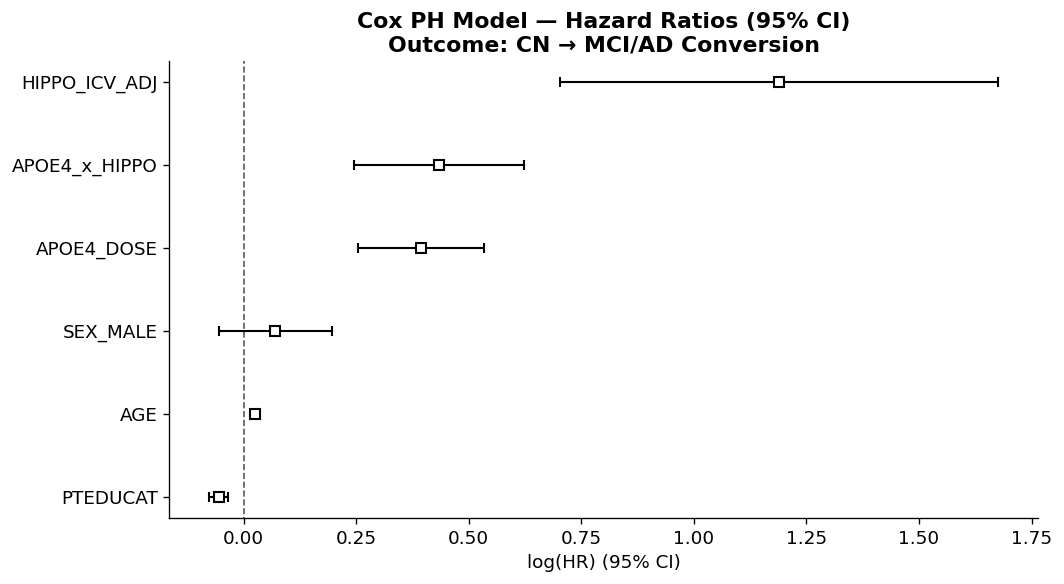

✓ Saved: Fig8_Cox_HazardRatios.png


In [40]:
if LIFELINES and has_event and 'surv_df' in locals() and len(surv_df) > 10:
    # Build Cox model predictors
    cox_vars = ['APOE4_DOSE', 'HIPPO_ICV_ADJ']
    for v in ['AGE', 'SEX_MALE', 'PTEDUCAT', 'GDTOTAL']:
        if v in surv_df.columns:
            cox_vars.append(v)
    
    # Add APOE×Hippo interaction
    surv_df['APOE4_x_HIPPO'] = surv_df['APOE4_DOSE'] * surv_df['HIPPO_ICV_ADJ']
    cox_vars.append('APOE4_x_HIPPO')
    
    cox_cols = ['TIME_YEARS', 'Event'] + cox_vars
    cox_data = surv_df[[c for c in cox_cols if c in surv_df.columns]].dropna().copy()
    
    print(f'Cox model data: {len(cox_data)} subjects, {cox_data["Event"].sum():.0f} events')
    print(f'Predictors: {[c for c in cox_vars if c in cox_data.columns]}')
    
    cph = CoxPHFitter(penalizer=0.1)  # small regularization for stability
    try:
        cph.fit(cox_data, duration_col='TIME_YEARS', event_col='Event')
        cph.print_summary()
        
        # Save Cox results
        cox_summary = cph.summary
        cox_summary.to_csv(os.path.join(REPORTS, 'Cox_PH_Results.csv'))
        print('\n✓ Saved: Cox_PH_Results.csv')
        
        # Forest plot of hazard ratios
        fig, ax = plt.subplots(figsize=(9, 5))
        cph.plot(ax=ax)
        ax.set_title('Cox PH Model — Hazard Ratios (95% CI)\nOutcome: CN → MCI/AD Conversion', fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(REPORTS, 'Fig8_Cox_HazardRatios.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print('✓ Saved: Fig8_Cox_HazardRatios.png')
        
    except Exception as e:
        print(f'Cox model failed: {e}')

elif not LIFELINES:
    print('lifelines not available — skipping Cox model')
else:
    print('Insufficient data for Cox model')

## 2. Sensitivity Analysis 1 — Stratified by Baseline Diagnosis
Run LME models separately for CN, MCI, and AD subgroups.

In [41]:
def build_covariates(df):
    cov_parts = []
    if 'AGE' in df.columns:      cov_parts.append('AGE')
    if 'SEX_MALE' in df.columns: cov_parts.append('SEX_MALE')
    if 'PTEDUCAT' in df.columns: cov_parts.append('PTEDUCAT')
    if 'GDTOTAL' in df.columns:  cov_parts.append('GDTOTAL')
    return ' + '.join(cov_parts)

def run_lme_simple(data, outcome, cov_str, label):
    """Fit LME with random intercept only (robust to small samples)"""
    if outcome not in data.columns:
        return None
    data_clean = data.dropna(subset=[outcome, 'YEARS_FROM_BL', 'APOE4_DOSE', 'HIPPO_ICV_ADJ']).copy()
    if 'GDTOTAL' in data_clean.columns:
        data_clean['GDTOTAL'] = data_clean['GDTOTAL'].fillna(0)
    
    # Need ≥2 visits per subject
    vc = data_clean.groupby('RID').size()
    data_clean = data_clean[data_clean['RID'].isin(vc[vc>=2].index)]
    
    n_sub = data_clean['RID'].nunique()
    if n_sub < 10:
        print(f'  {label}: only {n_sub} subjects — too few for LME, skipping')
        return None
    
    formula = f"{outcome} ~ YEARS_FROM_BL * APOE4_DOSE * HIPPO_ICV_ADJ" + \
              (f" + {cov_str}" if cov_str else "")
    
    # Align data with Patsy's NaN-dropping to prevent statsmodels index mismatch
    import patsy as _patsy
    try:
        _, _X = _patsy.dmatrices(formula, data=data_clean, return_type='dataframe')
        data_clean = data_clean.loc[_X.index].reset_index(drop=True)
        n_sub = data_clean['RID'].nunique()
    except Exception:
        data_clean = data_clean.reset_index(drop=True)
    
    try:
        # Try random slope first
        m = smf.mixedlm(formula, data=data_clean, groups=data_clean['RID'],
                        re_formula='~YEARS_FROM_BL')
        r = m.fit(method='lbfgs', maxiter=300, disp=False)
        if not np.isnan(r.llf):
            print(f'  {label}: n={n_sub}, random slope converged (AIC={r.aic:.1f})')
            return r
    except:
        pass
    
    try:
        m = smf.mixedlm(formula, data=data_clean, groups=data_clean['RID'])
        r = m.fit(method='lbfgs', maxiter=300, disp=False)
        print(f'  {label}: n={n_sub}, random intercept only (AIC={r.aic:.1f})')
        return r
    except Exception as e:
        print(f'  {label}: FAILED — {str(e)[:60]}')
        return None

print('=== SENSITIVITY 1: Stratified by Baseline Diagnosis ===')
print('MMSE models by BL diagnosis:\n')

strat_results = {}
for dx in ['CN', 'MCI', 'AD']:
    if 'BL_DX_LABEL' not in complete.columns:
        print(f'  BL_DX_LABEL not available — cannot stratify')
        break
    sub = complete[complete['BL_DX_LABEL'] == dx].copy()
    cov = build_covariates(sub)
    r = run_lme_simple(sub, 'MMSCORE', cov, f'MMSE-{dx}')
    strat_results[dx] = r

print('\nResults summary:')
for dx, r in strat_results.items():
    if r is not None:
        # Focus on key interaction terms
        key_terms = ['YEARS_FROM_BL', 'APOE4_DOSE', 'HIPPO_ICV_ADJ',
                     'YEARS_FROM_BL:APOE4_DOSE', 'YEARS_FROM_BL:HIPPO_ICV_ADJ']
        print(f'\n  {dx} stratum:')
        for t in key_terms:
            if t in r.fe_params:
                p = r.pvalues[t]
                print(f'    {t:<35} β={r.fe_params[t]:>7.3f}, p={"<0.001" if p<0.001 else f"{p:.3f}"}')

=== SENSITIVITY 1: Stratified by Baseline Diagnosis ===
MMSE models by BL diagnosis:

  MMSE-CN: n=766, random slope converged (AIC=nan)
  MMSE-MCI: n=981, random slope converged (AIC=nan)
  MMSE-AD: n=344, random slope converged (AIC=nan)

Results summary:

  CN stratum:
    YEARS_FROM_BL                       β=  0.146, p=0.229
    APOE4_DOSE                          β= -0.056, p=0.917
    HIPPO_ICV_ADJ                       β= -0.876, p=0.062
    YEARS_FROM_BL:APOE4_DOSE            β=  0.074, p=0.709
    YEARS_FROM_BL:HIPPO_ICV_ADJ         β= -0.350, p=0.041

  MCI stratum:
    YEARS_FROM_BL                       β=  0.328, p=0.355
    APOE4_DOSE                          β=  0.051, p=0.928
    HIPPO_ICV_ADJ                       β= -0.076, p=0.917
    YEARS_FROM_BL:APOE4_DOSE            β=  0.261, p=0.511
    YEARS_FROM_BL:HIPPO_ICV_ADJ         β= -1.148, p=0.020

  AD stratum:
    YEARS_FROM_BL                       β= -0.452, p=0.709
    APOE4_DOSE                          β=  0.2


✓ Saved: Sensitivity1_Stratified_Dx.csv


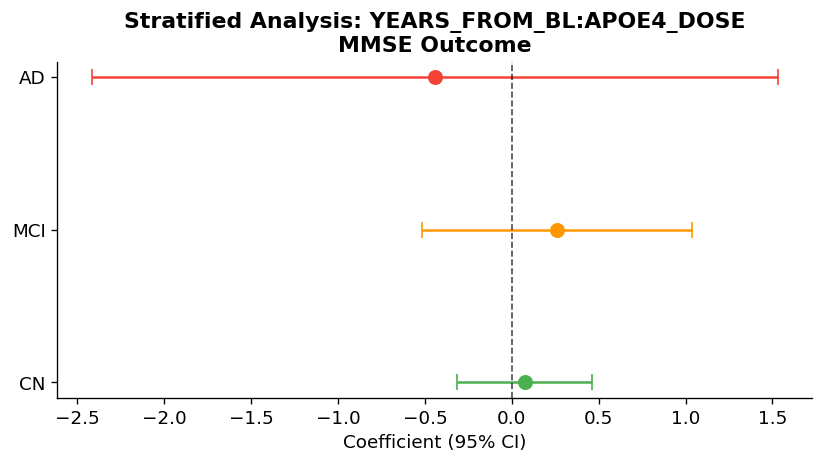

In [42]:
# Compare interaction coefficients across diagnostic groups (forest-style comparison)
if any(v is not None for v in strat_results.values()):
    target_term = 'YEARS_FROM_BL:APOE4_DOSE'
    alt_terms = ['YEARS_FROM_BL:APOE4_DOSE', 'YEARS_FROM_BL:HIPPO_ICV_ADJ', 'APOE4_DOSE']
    
    comparison_rows = []
    for dx, r in strat_results.items():
        if r is None: continue
        for term in alt_terms:
            if term in r.fe_params:
                comparison_rows.append({
                    'Diagnosis': dx, 'Term': term,
                    'Coef': r.fe_params[term],
                    'CI_lo': r.conf_int().loc[term, 0],
                    'CI_hi': r.conf_int().loc[term, 1],
                    'P_value': r.pvalues[term]
                })
    
    if comparison_rows:
        comp_df = pd.DataFrame(comparison_rows)
        comp_df.to_csv(os.path.join(REPORTS, 'Sensitivity1_Stratified_Dx.csv'), index=False)
        print('\n✓ Saved: Sensitivity1_Stratified_Dx.csv')
        
        # Plot comparison
        for term in alt_terms:
            sub = comp_df[comp_df['Term'] == term]
            if len(sub) < 2: continue
            
            fig, ax = plt.subplots(figsize=(7, 4))
            colors_dx = {'CN': '#4CAF50', 'MCI': '#FF9800', 'AD': '#F44336'}
            for _, row in sub.iterrows():
                dx = row['Diagnosis']
                ax.errorbar(row['Coef'], dx, 
                            xerr=[[row['Coef']-row['CI_lo']], [row['CI_hi']-row['Coef']]],
                            fmt='o', color=colors_dx.get(dx, 'grey'), capsize=5, markersize=8)
            ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
            ax.set_xlabel('Coefficient (95% CI)')
            ax.set_title(f'Stratified Analysis: {term}\nMMSE Outcome', fontweight='bold')
            plt.tight_layout()
            safe_term = term.replace(':', '_').replace('/', '_')
            plt.savefig(os.path.join(REPORTS, f'FigStrat_{safe_term}.png'), dpi=150, bbox_inches='tight')
            plt.show()
            break  # just first term

## 3. Sensitivity Analysis 2 — Exclude Hippocampal Outliers (±3 SD)

In [43]:
print('=== SENSITIVITY 2: Exclude Hippocampal Outliers (±3 SD) ===')

hippo_mean = complete['HIPPO_ICV_ADJ'].mean()
hippo_sd   = complete['HIPPO_ICV_ADJ'].std()
low_cut    = hippo_mean - 3*hippo_sd
high_cut   = hippo_mean + 3*hippo_sd

print(f'Hippocampal mean: {hippo_mean:.4f}, SD: {hippo_sd:.4f}')
print(f'Exclusion range: < {low_cut:.4f} or > {high_cut:.4f}')

outlier_mask = (complete['HIPPO_ICV_ADJ'] < low_cut) | (complete['HIPPO_ICV_ADJ'] > high_cut)
n_outliers = outlier_mask.sum()
print(f'Outliers: {n_outliers} observations ({n_outliers/len(complete)*100:.1f}%)')

no_outlier_df = complete[~outlier_mask].copy()
print(f'\nPost-exclusion: {no_outlier_df["RID"].nunique()} subjects, {len(no_outlier_df):,} obs')

cov_no = build_covariates(no_outlier_df)
if 'GDTOTAL' in no_outlier_df.columns:
    no_outlier_df['GDTOTAL'] = no_outlier_df['GDTOTAL'].fillna(0)

r_no_outlier = run_lme_simple(no_outlier_df, 'MMSCORE', cov_no, 'No-outlier MMSE')

if r_no_outlier is not None:
    print('\nKey terms (no-outlier model):')
    key_terms = ['YEARS_FROM_BL', 'APOE4_DOSE', 'HIPPO_ICV_ADJ',
                 'YEARS_FROM_BL:APOE4_DOSE', 'YEARS_FROM_BL:HIPPO_ICV_ADJ',
                 'YEARS_FROM_BL:APOE4_DOSE:HIPPO_ICV_ADJ']
    for t in key_terms:
        if t in r_no_outlier.fe_params:
            p = r_no_outlier.pvalues[t]
            print(f'  {t:<40} β={r_no_outlier.fe_params[t]:>8.4f}, p={"<0.001" if p<0.001 else f"{p:.3f}"}')

=== SENSITIVITY 2: Exclude Hippocampal Outliers (±3 SD) ===
Hippocampal mean: 0.7102, SD: 0.1169
Exclusion range: < 0.3596 or > 1.0607
Outliers: 161 observations (1.4%)

Post-exclusion: 2372 subjects, 11,632 obs
  No-outlier MMSE: n=2050, random slope converged (AIC=nan)

Key terms (no-outlier model):
  YEARS_FROM_BL                            β=  0.8703, p=<0.001
  APOE4_DOSE                               β= -0.5821, p=0.291
  HIPPO_ICV_ADJ                            β= -2.5877, p=<0.001
  YEARS_FROM_BL:APOE4_DOSE                 β= -0.1348, p=0.662
  YEARS_FROM_BL:HIPPO_ICV_ADJ              β= -1.8895, p=<0.001
  YEARS_FROM_BL:APOE4_DOSE:HIPPO_ICV_ADJ   β= -0.6148, p=0.166


## 4. Sensitivity Analysis 3 — Subjects with ≥2 Visits Only

In [44]:
print('=== SENSITIVITY 3: ≥2 Visits Only ===')

visit_counts = complete.groupby('RID').size()
multi_rids   = visit_counts[visit_counts >= 2].index
multi_df     = complete[complete['RID'].isin(multi_rids)].copy()

print(f'Original: {complete["RID"].nunique()} subjects')
print(f'≥2 visits: {multi_df["RID"].nunique()} subjects ({multi_df["RID"].nunique()/complete["RID"].nunique()*100:.1f}%)')
print(f'Mean visits: {visit_counts[multi_rids].mean():.1f}')

# Compare demographics between single vs multi-visit (check selection bias)
single_rids = visit_counts[visit_counts == 1].index
if len(single_rids) > 0:
    bl_multi  = baseline[baseline['RID'].isin(multi_rids)]
    bl_single = baseline[baseline['RID'].isin(single_rids)]
    
    print('\nSelection check — Multi-visit vs Single-visit subjects:')
    for var in ['AGE', 'MMSCORE', 'APOE4_DOSE', 'HIPPO_ICV_ADJ']:
        if var in bl_multi.columns:
            m_m = bl_multi[var].mean()
            m_s = bl_single[var].mean()
            _, p = stats.ttest_ind(bl_multi[var].dropna(), bl_single[var].dropna())
            print(f'  {var:<18} Multi: {m_m:.2f}  Single: {m_s:.2f}  p={"<0.001" if p<0.001 else f"{p:.3f}"}')

cov_multi = build_covariates(multi_df)
if 'GDTOTAL' in multi_df.columns:
    multi_df['GDTOTAL'] = multi_df['GDTOTAL'].fillna(0)

r_multi = run_lme_simple(multi_df, 'MMSCORE', cov_multi, '≥2-visit MMSE')

if r_multi is not None:
    print('\nKey terms (≥2 visits model):')
    for t in ['YEARS_FROM_BL:APOE4_DOSE', 'YEARS_FROM_BL:HIPPO_ICV_ADJ',
              'YEARS_FROM_BL:APOE4_DOSE:HIPPO_ICV_ADJ']:
        if t in r_multi.fe_params:
            p = r_multi.pvalues[t]
            print(f'  {t:<45} β={r_multi.fe_params[t]:>8.4f}, p={"<0.001" if p<0.001 else f"{p:.3f}"}')

=== SENSITIVITY 3: ≥2 Visits Only ===
Original: 2417 subjects
≥2 visits: 2143 subjects (88.7%)
Mean visits: 5.4

Selection check — Multi-visit vs Single-visit subjects:
  AGE                Multi: 73.11  Single: 71.03  p=<0.001
  MMSCORE            Multi: 27.39  Single: 27.24  p=0.386
  APOE4_DOSE         Multi: 0.55  Single: 0.50  p=0.219
  HIPPO_ICV_ADJ      Multi: 0.71  Single: 0.67  p=<0.001
  ≥2-visit MMSE: n=2091, random slope converged (AIC=nan)

Key terms (≥2 visits model):
  YEARS_FROM_BL:APOE4_DOSE                      β= -0.0823, p=0.755
  YEARS_FROM_BL:HIPPO_ICV_ADJ                   β= -2.0331, p=<0.001
  YEARS_FROM_BL:APOE4_DOSE:HIPPO_ICV_ADJ        β= -0.6861, p=0.066


## 5. Sensitivity Analysis 4 — Robust Standard Errors
MMSE has ceiling effects in CN subjects. Use robust SE to account for non-normality (Reviewer 2.3).

=== SENSITIVITY 4: MMSE Ceiling Effect & Robust Errors ===


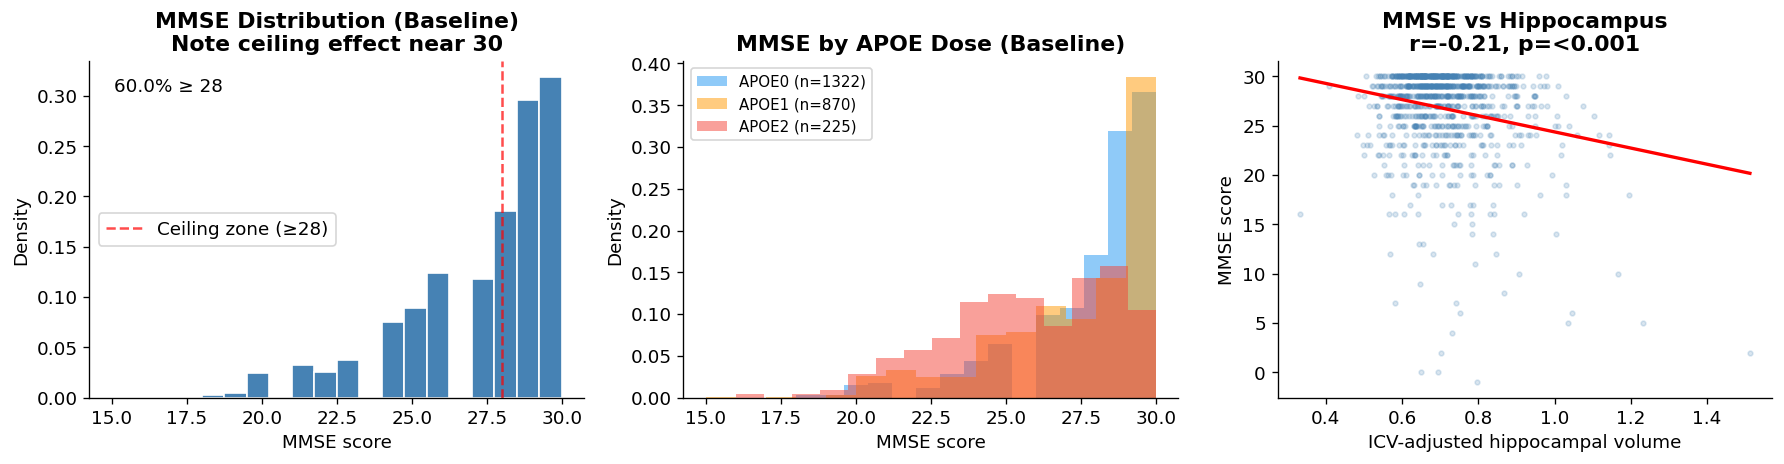

✓ Saved: FigSensitivity_MMSE_Distribution.png

MMSE ceiling analysis:
  Overall: 60.0% at ceiling (≥28)
  CN: 90.3% at ceiling
  MCI: 57.1% at ceiling
  AD: 0.7% at ceiling


In [45]:
print('=== SENSITIVITY 4: MMSE Ceiling Effect & Robust Errors ===')

# Show MMSE distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Overall MMSE distribution at baseline
ax = axes[0]
bl_mmse = baseline['MMSCORE'].dropna()
ax.hist(bl_mmse, bins=20, color='steelblue', edgecolor='white', density=True)
ax.axvline(28, color='red', linestyle='--', alpha=0.7, label='Ceiling zone (≥28)')
ax.set_xlabel('MMSE score')
ax.set_ylabel('Density')
ax.set_title('MMSE Distribution (Baseline)\nNote ceiling effect near 30', fontweight='bold')
ax.legend()
ceil_pct = (bl_mmse >= 28).mean() * 100
ax.text(0.05, 0.95, f'{ceil_pct:.1f}% ≥ 28', transform=ax.transAxes, va='top')

# MMSE by APOE dose at baseline
ax = axes[1]
for dose in [0, 1, 2]:
    sub = baseline[baseline['APOE4_DOSE'] == dose]['MMSCORE'].dropna()
    ax.hist(sub, bins=15, alpha=0.5, color=APOE_COLORS[dose],
            label=f'APOE{dose} (n={len(sub)})', edgecolor='none', density=True)
ax.set_xlabel('MMSE score')
ax.set_ylabel('Density')
ax.set_title('MMSE by APOE Dose (Baseline)', fontweight='bold')
ax.legend(fontsize=9)

# MMSE × Hippocampus scatter (all visits)
ax = axes[2]
if 'HIPPO_ICV_ADJ' in complete.columns:
    sample = complete.dropna(subset=['MMSCORE', 'HIPPO_ICV_ADJ']).sample(min(1000, len(complete)))
    ax.scatter(sample['HIPPO_ICV_ADJ'], sample['MMSCORE'],
               alpha=0.2, s=8, color='steelblue')
    slope, intercept, r, p, _ = stats.linregress(sample['HIPPO_ICV_ADJ'], sample['MMSCORE'])
    x = np.linspace(sample['HIPPO_ICV_ADJ'].min(), sample['HIPPO_ICV_ADJ'].max(), 100)
    ax.plot(x, slope*x + intercept, color='red', linewidth=2)
    ax.set_xlabel('ICV-adjusted hippocampal volume')
    ax.set_ylabel('MMSE score')
    ax.set_title(f'MMSE vs Hippocampus\nr={r:.2f}, p={"<0.001" if p<0.001 else f"{p:.3f}"}', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'FigSensitivity_MMSE_Distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: FigSensitivity_MMSE_Distribution.png')

# Apply floor/ceiling sensitivity analysis
print(f'\nMMSE ceiling analysis:')
print(f'  Overall: {(bl_mmse >= 28).mean()*100:.1f}% at ceiling (≥28)')
if 'BL_DX_LABEL' in baseline.columns:
    for dx in ['CN', 'MCI', 'AD']:
        sub = baseline[baseline['BL_DX_LABEL'] == dx]['MMSCORE'].dropna()
        if len(sub) > 0:
            print(f'  {dx}: {(sub >= 28).mean()*100:.1f}% at ceiling')

In [46]:
# Robust standard errors via statsmodels OLS with cluster-robust SE
# (as sensitivity to LME)
print('\nRobust SE approach — pooled OLS with cluster-robust SE (sensitivity check):')

robust_data = complete.dropna(subset=['MMSCORE', 'YEARS_FROM_BL', 'APOE4_DOSE', 'HIPPO_ICV_ADJ']).copy()
if 'GDTOTAL' in robust_data.columns:
    robust_data['GDTOTAL'] = robust_data['GDTOTAL'].fillna(0)

cov_parts = [v for v in ['AGE', 'SEX_MALE', 'PTEDUCAT', 'GDTOTAL'] if v in robust_data.columns]
if 'BL_DX_LABEL' in robust_data.columns:
    cov_parts.append('C(BL_DX_LABEL)')

formula_ols = ("MMSCORE ~ YEARS_FROM_BL * APOE4_DOSE * HIPPO_ICV_ADJ" +
               (f" + {' + '.join(cov_parts)}" if cov_parts else ""))

try:
    import patsy
    y, X = patsy.dmatrices(formula_ols, data=robust_data, return_type='dataframe')
    # Align groups to patsy's post-NaN-drop index
    robust_aligned = robust_data.loc[y.index].reset_index(drop=True)
    ols_model = sm.OLS(y, X)
    # Cluster-robust SE (clusters = subjects)
    ols_result_robust = ols_model.fit(cov_type='cluster', cov_kwds={'groups': robust_aligned['RID'].values})
    print(ols_result_robust.summary().tables[1])
    
    # Save
    with open(os.path.join(REPORTS, 'Sensitivity4_Robust_SE_MMSE.txt'), 'w') as f:
        f.write(ols_result_robust.summary().as_text())
    print('\n✓ Saved: Sensitivity4_Robust_SE_MMSE.txt')
except Exception as e:
    print(f'Robust SE failed: {e}')


Robust SE approach — pooled OLS with cluster-robust SE (sensitivity check):
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 24.3596      0.838     29.057      0.000      22.717      26.003
C(BL_DX_LABEL)[T.CN]                       7.0046      0.214     32.740      0.000       6.585       7.424
C(BL_DX_LABEL)[T.MCI]                      4.9433      0.216     22.867      0.000       4.520       5.367
YEARS_FROM_BL                              0.0513      0.156      0.329      0.742      -0.255       0.358
APOE4_DOSE                                 0.6538      0.575      1.136      0.256      -0.474       1.782
YEARS_FROM_BL:APOE4_DOSE                  -0.5298      0.296     -1.788      0.074      -1.111       0.051
HIPPO_ICV_ADJ                             -0.9692      0.698     -1

## 6. Sensitivity Results Summary Table

In [47]:
# Compile key interaction terms across sensitivity analyses
from importlib import import_module

print('=== SENSITIVITY ANALYSIS SUMMARY ===')
print('Key interaction term: Time × APOE4_DOSE × HIPPO_ICV_ADJ (3-way)\n')

def extract_term(result, term):
    if result is None or term not in result.fe_params: return None, None, None
    coef = result.fe_params[term]
    ci_lo = result.conf_int().loc[term, 0]
    ci_hi = result.conf_int().loc[term, 1]
    p = result.pvalues[term]
    return coef, (ci_lo, ci_hi), p

summary_rows = []
for label, res in [
    ('No outliers (±3 SD)', r_no_outlier),
    ('≥2 visits only',      r_multi),
    ('CN subgroup',         strat_results.get('CN')),
    ('MCI subgroup',        strat_results.get('MCI')),
    ('AD subgroup',         strat_results.get('AD')),
]:
    for term in ['YEARS_FROM_BL:APOE4_DOSE', 'YEARS_FROM_BL:HIPPO_ICV_ADJ']:
        coef, ci, p = extract_term(res, term)
        if coef is not None:
            summary_rows.append({
                'Analysis': label, 'Term': term,
                'Coef': round(coef, 4),
                'CI_95': f'[{ci[0]:.3f}, {ci[1]:.3f}]',
                'P_value': '<0.001' if p < 0.001 else f'{p:.3f}',
                'Sig': '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
            })

if summary_rows:
    sens_summary = pd.DataFrame(summary_rows)
    print(sens_summary.to_string(index=False))
    sens_summary.to_csv(os.path.join(REPORTS, 'Sensitivity_Summary_All.csv'), index=False)
    print('\n✓ Saved: Sensitivity_Summary_All.csv')
else:
    print('No sensitivity results available to compile')

=== SENSITIVITY ANALYSIS SUMMARY ===
Key interaction term: Time × APOE4_DOSE × HIPPO_ICV_ADJ (3-way)

           Analysis                        Term    Coef            CI_95 P_value Sig
No outliers (±3 SD)    YEARS_FROM_BL:APOE4_DOSE -0.1348  [-0.739, 0.470]   0.662    
No outliers (±3 SD) YEARS_FROM_BL:HIPPO_ICV_ADJ -1.8895 [-2.601, -1.177]  <0.001 ***
     ≥2 visits only    YEARS_FROM_BL:APOE4_DOSE -0.0823  [-0.599, 0.434]   0.755    
     ≥2 visits only YEARS_FROM_BL:HIPPO_ICV_ADJ -2.0331 [-2.678, -1.388]  <0.001 ***
        CN subgroup    YEARS_FROM_BL:APOE4_DOSE  0.0742  [-0.315, 0.464]   0.709    
        CN subgroup YEARS_FROM_BL:HIPPO_ICV_ADJ -0.3499 [-0.686, -0.014]   0.041   *
       MCI subgroup    YEARS_FROM_BL:APOE4_DOSE  0.2608  [-0.516, 1.038]   0.511    
       MCI subgroup YEARS_FROM_BL:HIPPO_ICV_ADJ -1.1484 [-2.116, -0.180]   0.020   *
        AD subgroup    YEARS_FROM_BL:APOE4_DOSE -0.4425  [-2.417, 1.532]   0.661    
        AD subgroup YEARS_FROM_BL:HIPPO_ICV_ADJ 

## 7. Output Summary

In [48]:
print('SURVIVAL & SENSITIVITY ANALYSIS COMPLETE')
print('='*60)
print('\nFiles in reports/:')
for f in sorted(os.listdir(REPORTS)):
    size = os.path.getsize(os.path.join(REPORTS, f)) / 1024
    print(f'  {f:<50} {size:>8.1f} KB')

SURVIVAL & SENSITIVITY ANALYSIS COMPLETE

Files in reports/:
  ADNI_Baseline_Analysis.csv                            565.7 KB
  ADNI_Complete_Cases.csv                              2945.4 KB
  ADNI_Data_Quality_Report.txt                            1.1 KB
  ADNI_Longitudinal_Analysis.csv                       2886.3 KB
  ADNI_Master_Longitudinal.csv                         3340.6 KB
  ADNI_Table1_Characteristics.csv                         0.8 KB
  Cox_PH_Results.csv                                      1.3 KB
  Fig1_APOE_Distribution.png                             96.7 KB
  Fig2_Cognition_by_APOE.png                            320.3 KB
  Fig3_Hippocampus_by_APOE.png                          119.4 KB
  Fig4_MMSE_Trajectories_Preview.png                    293.3 KB
  Fig5_Missing_Data.png                                 152.0 KB
  Fig6_Hippo_MMSE_Scatter.png                           190.5 KB
  Fig7_KaplanMeier.png                                  115.1 KB
  Fig8_Cox_HazardRatios.png  